In [9]:
# Jupyter notebook display configuration
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

# Required for napari in notebooks
%gui qt

# Standard library
from glob import glob
import os
import pathlib
import random
import re

# Core scientific/plotting
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colors import Normalize
from PIL import Image

# File handling
import h5py

# Dask (out-of-memory computation)
import dask.array as da
import dask_image.ndmorph as damorph
from dask.cache import Cache

# Image I/O
from tifffile import imread as tiff_imread
from skimage.io import imread as skio_imread

# Image viewer and animation
import napari
from napari.utils.notebook_display import nbscreenshot
from napari_animation import Animation

# SciPy (stats, signal, ndimage)
from scipy.ndimage import label as nd_label
from scipy.signal import find_peaks
from scipy.stats import gaussian_kde

# scikit-image
from skimage import filters, morphology, draw
from skimage.draw import ellipse
from skimage.morphology import binary_closing, disk
from skimage.measure import regionprops, regionprops_table, label as sk_label

# Dask cache (optional)
cache = Cache(2e9)  # Leverage 2 GB of memory
cache.register()    # Turn cache on globally


Colony Tracking with Frame Persistence Filtering

This script tracks yeast colonies across multiple time-lapse image positions, assigns globally unique colony IDs, handles merged colonies, and filters out short-lived detections.

Key Features:

- Input:
  - 3D binary masks (`colonies_mask.npy`) from multiple positions.

- Tracking:
  - Colonies are labeled per frame using `skimage.measure.label`.
  - IDs are propagated across frames based on spatial overlap.
  - Merged colonies are assigned IDs offset by `MERGED_ID_OFFSET`.

- Global Uniqueness:
  - Colony IDs are globally unique across all positions using shared counters.

- Filtering:
  - Colonies must appear in more than `FILTER` frames (default: 3) to be retained.

- Output:
  - `tracking_df`: all tracking data across frames and positions.
  - `first_colonies_df`: metadata for first appearance of each colony.
  - `non_merged_df`: filtered summary of non-merged colonies.

Summary Output:

The script prints the number of non-merged, persistent colonies per position after filtering.


In [ ]:
# Initialize global tracking containers
all_tracking_data = []
all_first_colonies_data = []

# Base directory for positions
data_archive_path = '/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2026/BioImageArchive/'

# input and output paths relative to BioImageArchive location
base_dir = os.path.join(data_archive_path, 'ToleranceAssay/S9_wt_AB-gradient/replicate_1')

positions = ['pos1', 'pos2', 'pos3', 'pos4', 'pos5', 'pos6', 'pos7', 'pos8', 'pos9', 'pos10']

MERGED_ID_OFFSET = 1000000000  # Offset to distinguish merged colonies
FILTER = 3  # Minimum number of frames a colony must appear in

# Global frame count dictionary
colony_frame_counts = {}

# Global counters (shared across all positions)
global_colony_id_counter = 1
global_merged_colony_counter = 1

# Process each position
for pos in positions:
    colonies_mask_path = os.path.join(base_dir, pos, 'colonies_mask.npy')
    colonies_mask = np.load(colonies_mask_path)

    tracking_data = []
    merged_colony_map = {}
    first_colonies_appearance = set()
    first_colonies_appearance_data = []

    previous_colony_labels = None
    previous_colony_ids = None

    for frame_idx in range(len(colonies_mask)):
        current_colony_labels, num_colonies = label(colonies_mask[frame_idx], return_num=True)
        current_colony_ids = {}

        if previous_colony_labels is not None:
            for current_label in range(1, num_colonies + 1):
                current_mask = current_colony_labels == current_label
                overlap = previous_colony_labels[current_mask]
                overlapping_colonies = np.unique(overlap[overlap > 0])

                if len(overlapping_colonies) > 1:
                    previous_ids = np.array([previous_colony_ids[label] for label in overlapping_colonies])
                    if np.any(previous_ids >= MERGED_ID_OFFSET):
                        merged_id = np.min(previous_ids[previous_ids >= MERGED_ID_OFFSET])
                    else:
                        merged_id = MERGED_ID_OFFSET + global_merged_colony_counter
                        global_merged_colony_counter += 1
                    current_colony_ids[current_label] = merged_id
                    merged_colony_map[current_label] = merged_id
                elif len(overlapping_colonies) == 1:
                    overlapping_label = overlapping_colonies[0]
                    current_colony_ids[current_label] = previous_colony_ids[overlapping_label]
                else:
                    current_colony_ids[current_label] = global_colony_id_counter
                    global_colony_id_counter += 1
        else:
            for current_label in range(1, num_colonies + 1):
                current_colony_ids[current_label] = global_colony_id_counter
                global_colony_id_counter += 1

        # Track data and update frame counts
        for region in regionprops(current_colony_labels):
            colony_id = current_colony_ids[region.label]

            # Update frame count
            colony_frame_counts[colony_id] = colony_frame_counts.get(colony_id, 0) + 1

            if colony_id not in first_colonies_appearance:
                first_colonies_appearance.add(colony_id)
                first_colonies_appearance_data.append({
                    "position": pos,
                    "frame": frame_idx,
                    "colony_id": colony_id,
                    "area": region.area,
                    "centroid": region.centroid,
                    "bbox": region.bbox,
                    "replicate": "replicate1"
                })

            tracking_data.append({
                "position": pos,
                "frame": frame_idx,
                "colony_id": colony_id,
                "area": region.area,
                "centroid": region.centroid,
                "bbox": region.bbox,
                "replicate": "replicate1"
            })

        previous_colony_labels = current_colony_labels
        previous_colony_ids = current_colony_ids

    all_tracking_data.extend(tracking_data)
    all_first_colonies_data.extend(first_colonies_appearance_data)

# Convert to DataFrames
tracking_df = pd.DataFrame(all_tracking_data)
first_colonies_df = pd.DataFrame(all_first_colonies_data)

# Apply frame count filter
valid_colonies = [col_id for col_id, count in colony_frame_counts.items() if count > FILTER]
tracking_df = tracking_df[tracking_df['colony_id'].isin(valid_colonies)]
first_colonies_df = first_colonies_df[first_colonies_df['colony_id'].isin(valid_colonies)]

# Filter non-merged colonies
non_merged_df = first_colonies_df[first_colonies_df['colony_id'] < MERGED_ID_OFFSET]

# Print summary
print("Non-merged colony counts per position (filtered):")
print(non_merged_df.groupby('position')['colony_id'].nunique())


Colony Filtering Based on Growth Threshold

This code filters tracked colonies based on their growth from the first to the last frame, retaining only those that meet a specified minimum growth factor.

Key Steps:

- Parameters:
  - `GROWTH_THRESHOLD`: minimum required growth factor (default: 1.3).

- Step 1: Compute Growth Factor
  - Sort `tracking_df` by `colony_id` and `frame`.
  - For each colony, calculate the ratio of final to initial area.

- Step 2: Select Valid Colonies
  - Retain colonies with a growth factor greater than or equal to the threshold.

- Step 3: Filter DataFrames
  - Keep only valid colonies in both `tracking_df` and `first_colonies_df`.

- Step 4: Filter Non-Merged Colonies
  - Exclude colonies with IDs above `MERGED_ID_OFFSET`.

- Step 5: Output
  - Print the number of non-merged, growing colonies per position.


In [ ]:
# Parameters
GROWTH_THRESHOLD = 1.3

# Step 1: Compute growth factor from first to last frame per colony
tracking_df_sorted = tracking_df.sort_values(by=['colony_id', 'frame'])
colony_endpoints = tracking_df_sorted.groupby('colony_id')['area'].agg(['first', 'last'])
colony_endpoints['growth_factor'] = colony_endpoints['last'] / colony_endpoints['first']

# Step 2: Keep only colonies that meet the growth threshold
valid_colonies = set(colony_endpoints[colony_endpoints['growth_factor'] >= GROWTH_THRESHOLD].index)

# Step 3: Filter tracking_df and first_colonies_df to include only valid colonies
tracking_df = tracking_df[tracking_df['colony_id'].isin(valid_colonies)].copy()
first_colonies_df = first_colonies_df[first_colonies_df['colony_id'].isin(valid_colonies)].copy()

# Step 4: Filter to non-merged colonies only
non_merged_df = first_colonies_df[first_colonies_df['colony_id'] < MERGED_ID_OFFSET]

# Step 5: Print summary
print("\nNon-merged colony counts per position (after strict growth filter):")
print(non_merged_df.groupby('position')['colony_id'].nunique())


Exporting Non-Merged Colony Data

This code prepares and exports a CSV file containing metadata for non-merged colonies detected in the first frame they appear.

Key Steps:

- Exclude Merged Colonies:
  - Filter `first_colonies_df` to include only colonies with IDs below `MERGED_ID_OFFSET`.

- Format Centroid Coordinates:
  - Extract `x` and `y` from the centroid tuple (note: skimage uses (row, col) = (y, x)).

- Create Export DataFrame:
  - Include `colony_id`, `x`, `y`, `frame`, `position`, and `replicate`.

- Save to CSV:
  - Write the formatted DataFrame to the specified `OUTPUT_PATH`.

- Output:
  - Print confirmation and the number of colonies exported.


In [ ]:
# --- Exclude merged colonies ---
# This step removes colonies with IDs ≥ MERGED_ID_OFFSET for export
colonies_to_export = first_colonies_df[
    first_colonies_df['colony_id'] < MERGED_ID_OFFSET
].copy()

# --- Create a new DataFrame with separate x and y columns for saving ---
# Note: Centroid from skimage is (row, col), which corresponds to (y, x)
final_export_df = pd.DataFrame({
    'colony_id': colonies_to_export['colony_id'],
    'x': colonies_to_export['centroid'].apply(lambda c: c[1] if isinstance(c, tuple) else np.nan),
    'y': colonies_to_export['centroid'].apply(lambda c: c[0] if isinstance(c, tuple) else np.nan),
    'frame': colonies_to_export['frame'],
    'position': colonies_to_export['position'],
    'replicate': "replicate1"
})

# --- Define the output path and save ---
OUTPUT_PATH = '2_first_colonies_ab_gradient.csv'
final_export_df.to_csv(OUTPUT_PATH, index=False)

# --- Print final status ---
print("\n--- Saving Process Complete ---")
print(f"Excluded merged colonies. Final count for export: {len(final_export_df)}")
print(f"✅ Data saved successfully to: {OUTPUT_PATH}")


This script visualizes first-appearance colonies in **Napari** using a time-lapse PNG stack.

- Goal: Display numeric colony labels (`text='colony_id'`), allow adding and deleting points, then update the CSV (append added, remove deleted).
- Data interpretation: Points are `(frame, y, x)`; move the time slider to the correct frame before clicking.
- Colony IDs:
  - Existing points show their `colony_id`.
  - New points get sequential `colony_id` values starting after the max for the selected `position`.
- Layers:
  - Image: mCherry PNG stack.
  - Colonies: existing detections (yellow dots with labels), editable for deletion.
  - NewPoints: newly added detections (cyan dots with labels).
- Actions:
  - Add: select `NewPoints`, enable the “+” tool, click to place points.
  - Delete: select `Colonies`, use the “Select” tool, click point(s), press Delete/Backspace.
- Save on close:
  - After closing Napari, the script removes deleted `colony_id`s (for the chosen `position`) and appends newly added points with their assigned IDs, then writes back to the CSV.

In [ ]:
#positions = ['pos0', 'pos1', 'pos2', 'pos3', 'pos4', 'pos5', 'pos6', 'pos7', 'pos8', 'pos9]

# --------------------------
# Configuration (edit as needed)
# --------------------------
csv_path = '2_first_colonies_ab_gradient.csv'
pos = 'pos10'  # position you are annotating
png_dir = "/Volumes/ScientificData/Users/Giulia(botgiu00)/Papers/bottacin2025/Image_Data/Figure2/2S_ab_gradient/replicate_1/pos10/mcherry/cut_im"
png_glob = "20250408_AB_gradient_pos10_mcherry_frame*_cut.png"  # Matches all frames

# --------------------------
# Load CSV
# --------------------------
if not os.path.exists(csv_path):
    raise FileNotFoundError(f"CSV not found: {csv_path}")

df = pd.read_csv(csv_path)

# --------------------------
# Compute global max ID safely
# --------------------------
if 'colony_id' in df.columns and df['colony_id'].notna().any():
    global_max_id = int(df['colony_id'].dropna().max())
else:
    global_max_id = 0

# --------------------------
# Load PNG stack
# --------------------------
png_files = sorted(glob(os.path.join(png_dir, png_glob)))
if len(png_files) == 0:
    raise FileNotFoundError(f"No PNGs found with pattern: {os.path.join(png_dir, png_glob)}")

stack = np.stack([np.array(Image.open(f)) for f in png_files], axis=0)
print(f"Loaded stack: {stack.shape} (T, Y, X) with {len(png_files)} frames")

# --------------------------
# Prepare existing detections for this position
# --------------------------
sub = df[df['position'] == pos].copy()

if len(sub):
    points = np.asarray(
        [[int(row['frame']), float(row['y']), float(row['x'])] for _, row in sub.iterrows()],
        dtype=float
    )
    props = {'colony_id': sub['colony_id'].astype(int).to_numpy()}
else:
    points = np.empty((0, 3), dtype=float)
    props = {'colony_id': np.array([], dtype=int)}

orig_ids = set(props['colony_id'].tolist()) if len(props['colony_id']) else set()

# --------------------------
# Launch napari
# --------------------------
viewer = napari.Viewer()
viewer.add_image(stack, name='mCherry PNG stack', colormap='magenta')

# Existing colonies
colonies_layer = viewer.add_points(
    points,
    name='Colonies',
    ndim=3,
    properties=props,
    face_color='yellow',
    edge_color='black',
    edge_width=0.5,
    size=6,
    symbol='o',
    text='colony_id'
)
colonies_layer.editable = True
colonies_layer.mode = 'select'

# New colonies
new_layer = viewer.add_points(
    data=np.empty((0, 3), dtype=float),
    name='NewPoints',
    ndim=3,
    face_color='cyan',
    edge_color='black',
    edge_width=0.5,
    size=6,
    symbol='o'
)
new_layer.properties = {'colony_id': np.array([], dtype=int)}
new_layer.text = 'colony_id'

# --------------------------
# ID updater
# --------------------------
def _update_new_ids(event=None):
    global global_max_id

    if len(new_layer.data) == 0:
        new_layer.properties['colony_id'] = np.array([], dtype=int)
        return

    current_ids = new_layer.properties.get('colony_id', np.array([], dtype=int))
    n_existing = len(current_ids)
    n_total = len(new_layer.data)

    if n_total > n_existing:
        start = global_max_id + n_existing + 1
        new_ids = np.arange(start, start + (n_total - n_existing), dtype=int)
        new_layer.properties['colony_id'] = np.concatenate([current_ids, new_ids])
    elif n_total < n_existing:
        new_layer.properties['colony_id'] = current_ids[:n_total]

new_layer.events.data.connect(_update_new_ids)

# Route clicks to NewPoints
new_layer.editable = True
new_layer.selected = True
new_layer.mode = 'add'

print("Napari is open.")
print("- Add: select 'NewPoints' (cyan), '+' tool, click to add.")
print("- Delete: select 'Colonies' (yellow numbers), 'Select' tool, click → Delete/Backspace.")
print("Close the window when done.")
napari.run()  # blocks until closed

Loaded stack: (180, 701, 735) (T, Y, X) with 180 frames
Napari is open.
- Add: select 'NewPoints' (cyan), '+' tool, click to add.
- Delete: select 'Colonies' (yellow numbers), 'Select' tool, click → Delete/Backspace.
Close the window when done.


/Users/giuliabottacin/miniforge3/envs/i2i_p0_env/lib/python3.9/site-packages/napari/layers/base/base.py:1583: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
/Users/giuliabottacin/miniforge3/envs/i2i_p0_env/lib/python3.9/site-packages/napari/layers/base/base.py:1583: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
/Users/giuliabottacin/miniforge3/envs/i2i_p0_env/lib/python3.9/site-packages/napari/layers/base/base.py:1583: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
/Users/giuliabottacin/miniforge3/envs/i2i_p0_env/lib/python3.9/site-packages/napari/layers/base/base.py:1583: RuntimeWarning: invalid value encountered in cast
  corners[:, displayed_axes] = data_bbox_clipped
/Users/giuliabottacin/miniforge3/envs/i2i_p0_env/lib/python3.9/site-packages/napari/layers/base/base.py:1583: RuntimeWarning: invalid value encountered in cast
  co

In [45]:
# --------------------------
# After closing napari: apply deletions and additions
# --------------------------
_update_new_ids()  # ensure IDs are up-to-date

# Track remaining and removed colonies
remaining_ids = set(map(int, colonies_layer.properties.get('colony_id', []))) if hasattr(colonies_layer, 'properties') else set()
orig_ids = set(df[df['position'] == pos]['colony_id'].dropna().astype(int)) if 'colony_id' in df.columns else set()
removed_ids = orig_ids - remaining_ids

# Gather new points
new_data = new_layer.data
new_ids = new_layer.properties.get('colony_id', np.array([], dtype=int))
new_ids = new_ids[~np.isnan(new_ids)].astype(int)  # remove any NaN

added_n = int(new_data.shape[0]) if new_data is not None else 0
removed_n = len(removed_ids)

# Determine replicate for this position
if 'replicate' in df.columns and len(df[df['position'] == pos]) > 0:
    replicate_val = df[df['position'] == pos]['replicate'].iloc[0]
else:
    replicate_val = 'replicate_1'  # default

# Build DataFrame for new points
if added_n > 0:
    if len(new_ids) != added_n:
        max_id_pos = int(df[df['position'] == pos]['colony_id'].max()) if len(df[df['position'] == pos]) else 0
        new_ids = np.arange(max_id_pos + 1, max_id_pos + added_n + 1, dtype=int)

    to_append = pd.DataFrame({
        'position': [pos] * added_n,
        'frame': new_data[:, 0].astype(int),
        'y': new_data[:, 1].astype(float),
        'x': new_data[:, 2].astype(float),
        'colony_id': new_ids,
        'replicate': [replicate_val] * added_n
    })
else:
    to_append = pd.DataFrame(columns=['position', 'frame', 'y', 'x', 'colony_id', 'replicate'])

# Update CSV safely
if removed_n > 0:
    df = df[~((df['position'] == pos) & (df['colony_id'].isin(list(removed_ids))))]

if added_n > 0:
    df = pd.concat([df, to_append], ignore_index=True)

# Write via temporary file
tmp_csv = csv_path + ".tmp"
df.to_csv(tmp_csv, index=False)
shutil.move(tmp_csv, csv_path)

# Summary
if removed_n > 0:
    removed_str = ", ".join(map(str, sorted(removed_ids)))
    print(f"Deleted {removed_n} colonies for position '{pos}' (IDs: {removed_str}).")
if added_n > 0:
    print(f"Appended {added_n} new colonies for position '{pos}' with IDs "
          f"{to_append['colony_id'].min()}–{to_append['colony_id'].max()} (replicate: {replicate_val}).")

print("Done.")

Deleted 23 colonies for position 'pos10' (IDs: 29579, 29589, 29596, 29602, 29603, 29609, 29610, 29612, 29614, 29617, 29638, 29639, 29647, 29651, 29653, 29669, 29674, 29688, 29696, 29750, 29751, 29755, 29794).
Appended 9 new colonies for position 'pos10' with IDs 29868–29876 (replicate: replicate1).
Done.


This script removes manually flagged colonies from the exported dataset. It includes:

- **Loading the CSV** (```2_first_colonies_wt_rep1.csv```) into a DataFrame.
- **Filtering out specific ```colony_id```s** per ```position``` using a predefined dictionary.
- **Saving the cleaned DataFrame** back to the same file.
- **Confirmation message** printed upon completion.

This ensures that unwanted or artifact colonies are excluded from downstream analysis.

This script visualizes the spatial distribution and appearance time of first colonies per position. It includes:

- **Loading the CSV** with colony coordinates and metadata.
- **Computing appearance time in hours** from frame number (```frame × 5/60```).
- **Creating a subplot for each position**:
  - Plots colony centroids in microns (```x```, ```y``` scaled by 0.065 µm/pixel).
  - Colors points by appearance time using the ```'viridis'``` colormap.
  - Labels each point with its ```colony_id```.
  - Adds axis labels, titles, and colorbars.
  - Inverts the y-axis to match image coordinates.

This plot helps assess **spatial and temporal patterns** of colony emergence across different fields of view.

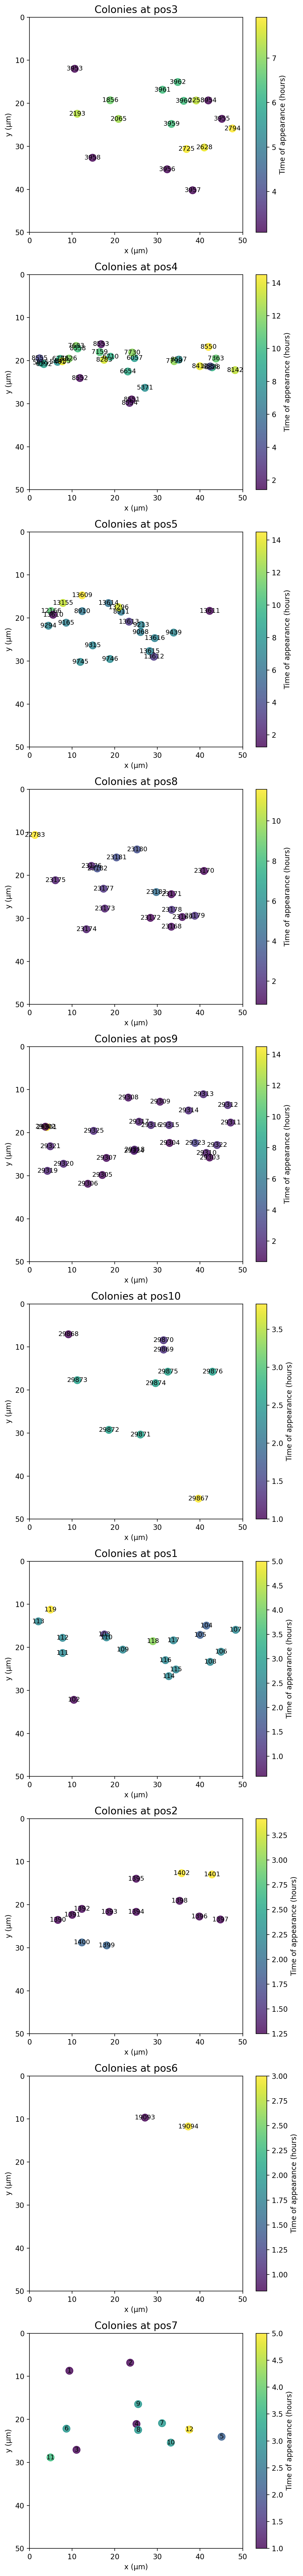

In [ ]:
# Load the exported DataFrame with x and y columns
csv_path = '2_first_colonies_ab_gradient.csv'
first_colonies_df = pd.read_csv(csv_path)

# Calculate time in hours if not already in the DataFrame
first_colonies_df['hours'] = first_colonies_df['frame'] * (5 / 60)

positions = first_colonies_df['position'].unique()
fig, axes = plt.subplots(len(positions), 1, figsize=(6, 5 * len(positions)))

if len(positions) == 1:
    axes = [axes]

for ax, pos in zip(axes, positions):
    subset = first_colonies_df[first_colonies_df['position'] == pos]
    
    x_um = subset['x'] * 0.065
    y_um = subset['y'] * 0.065
    hours = subset['hours']

    sc = ax.scatter(x_um, y_um, c=hours, cmap='viridis', s=100, alpha=0.8)
    
    for _, row in subset.iterrows():
        ax.text(row['x'] * 0.065, row['y'] * 0.065, str(row['colony_id']), fontsize=9, ha='center', va='center')

    ax.set_title(f'Colonies at {pos}', fontsize=14)
    ax.set_xlabel('x (µm)')
    ax.set_ylabel('y (µm)')
    ax.set_xlim(0, 50)
    ax.set_ylim(0, 50)
    ax.invert_yaxis()
    ax.grid(False)

    # Add colorbar for each plot
    cbar = plt.colorbar(sc, ax=ax)
    cbar.set_label('Time of appearance (hours)')

plt.tight_layout()
plt.show()